In [2]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
import matplotlib as mpl

# 解决中文显示问题 - 使用更通用的字体配置方法
import platform
system = platform.system()

# 根据操作系统设置合适的字体
if system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
elif system == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'Arial']
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'Arial']

plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 使用英文标签代替中文标签，避免字体问题
use_english_labels = True

In [3]:
'''
## 1. 数据加载与预处理
'''

# 读取CSV文件
df = pd.read_csv('women.csv', index_col=0)

# 显示原始数据的前几行
print("Original Data (inches and pounds):" if use_english_labels else "原始数据(英寸和磅)：")
print(df.head())

# 查看数据的基本统计信息
print("\nData Statistics:" if use_english_labels else "\n数据统计信息：")
print(df.describe())

Original Data (inches and pounds):
   height  weight
1      58     115
2      59     117
3      60     120
4      61     123
5      62     126

Data Statistics:
          height      weight
count  15.000000   15.000000
mean   65.000000  136.733333
std     4.472136   15.498694
min    58.000000  115.000000
25%    61.500000  124.500000
50%    65.000000  135.000000
75%    68.500000  148.000000
max    72.000000  164.000000


In [4]:
'''
## 2. 单位转换
将身高从英寸转换为厘米(cm)，将体重从磅转换为千克(kg)
'''

# 单位转换常数
INCH_TO_CM = 2.54  # 1英寸 = 2.54厘米
POUND_TO_KG = 0.45359237  # 1磅 = 0.45359237千克

# 创建新的DataFrame，包含转换后的单位
df_metric = df.copy()
df_metric['height_cm'] = df['height'] * INCH_TO_CM
df_metric['weight_kg'] = df['weight'] * POUND_TO_KG

# 显示转换后的数据
print("Converted Data (cm and kg):" if use_english_labels else "转换后的数据(厘米和千克)：")
print(df_metric.head())

# 数据统计信息
print("\nConverted Data Statistics:" if use_english_labels else "\n转换后数据统计信息：")
print(df_metric[['height_cm', 'weight_kg']].describe())

Converted Data (cm and kg):
   height  weight  height_cm  weight_kg
1      58     115     147.32  52.163123
2      59     117     149.86  53.070307
3      60     120     152.40  54.431084
4      61     123     154.94  55.791862
5      62     126     157.48  57.152639

Converted Data Statistics:
        height_cm  weight_kg
count   15.000000  15.000000
mean   165.100000  62.021197
std     11.359225   7.030089
min    147.320000  52.163123
25%    156.210000  56.472250
50%    165.100000  61.234970
75%    173.990000  67.131671
max    182.880000  74.389149


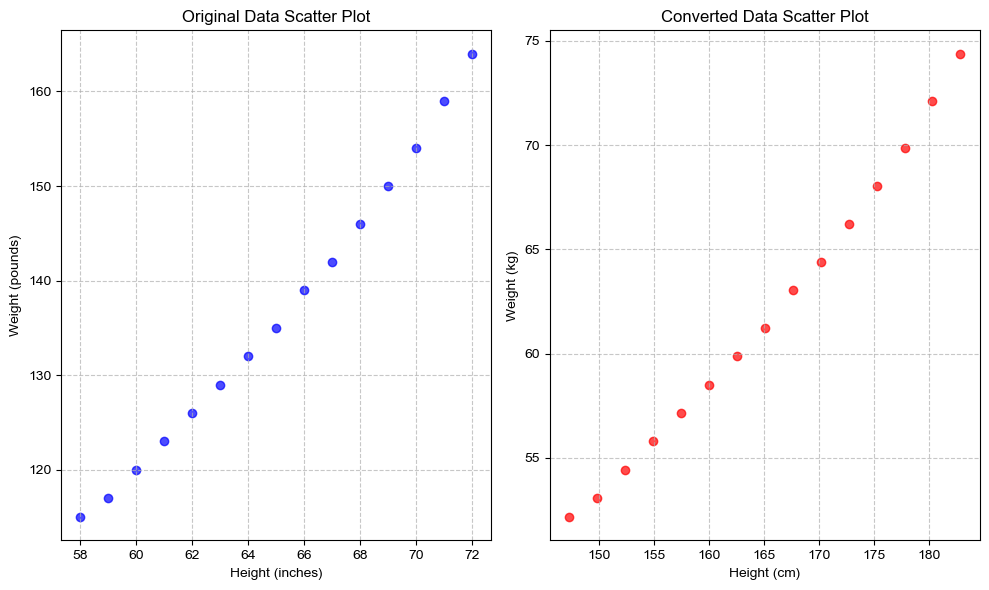

In [5]:
'''
## 3. 数据可视化
'''

# 绘制散点图，观察身高和体重的关系
plt.figure(figsize=(10, 6))

# 原始数据散点图（英寸vs磅）
plt.subplot(1, 2, 1)
plt.scatter(df['height'], df['weight'], color='blue', alpha=0.7)
plt.title('Original Data Scatter Plot' if use_english_labels else '原始数据散点图')
plt.xlabel('Height (inches)' if use_english_labels else '身高 (英寸)')
plt.ylabel('Weight (pounds)' if use_english_labels else '体重 (磅)')
plt.grid(True, linestyle='--', alpha=0.7)

# 转换后的数据散点图（厘米vs千克）
plt.subplot(1, 2, 2)
plt.scatter(df_metric['height_cm'], df_metric['weight_kg'], color='red', alpha=0.7)
plt.title('Converted Data Scatter Plot' if use_english_labels else '转换后数据散点图')
plt.xlabel('Height (cm)' if use_english_labels else '身高 (厘米)')
plt.ylabel('Weight (kg)' if use_english_labels else '体重 (千克)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('scatter_plot_comparison.png')  # 保存图片的英文名称
plt.show()

In [6]:
'''
## 4. 线性回归分析
'''

# 准备数据
X = df_metric['height_cm'].values.reshape(-1, 1)  # 自变量：身高(cm)
y = df_metric['weight_kg'].values  # 因变量：体重(kg)

# 创建线性回归模型
linear_model = LinearRegression()

# 拟合模型
linear_model.fit(X, y)

# 预测值
y_pred_linear = linear_model.predict(X)

# 计算拟合优度
r2_linear = r2_score(y, y_pred_linear)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Regression Model:" if use_english_labels else f"线性回归模型：")
print(f"Slope (coefficient): {linear_model.coef_[0]:.4f}" if use_english_labels else f"斜率(系数): {linear_model.coef_[0]:.4f}")
print(f"Intercept: {linear_model.intercept_:.4f}" if use_english_labels else f"截距: {linear_model.intercept_:.4f}")
print(f"Equation: Weight(kg) = {linear_model.coef_[0]:.4f} × Height(cm) + {linear_model.intercept_:.4f}" if use_english_labels else 
      f"方程式: 体重(kg) = {linear_model.coef_[0]:.4f} × 身高(cm) + {linear_model.intercept_:.4f}")
print(f"R²: {r2_linear:.4f}")
print(f"Mean Squared Error (MSE): {mse_linear:.4f}" if use_english_labels else f"均方误差(MSE): {mse_linear:.4f}")

Linear Regression Model:
Slope (coefficient): 0.6161
Intercept: -39.6969
Equation: Weight(kg) = 0.6161 × Height(cm) + -39.6969
R²: 0.9910
Mean Squared Error (MSE): 0.4147


In [7]:
'''
## 5. 非线性回归分析
我们将尝试多项式回归(二次多项式)作为非线性回归的一种方法
'''

# 创建二次多项式回归模型
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())

# 拟合模型
poly_model.fit(X, y)

# 预测值
y_pred_poly = poly_model.predict(X)

# 获取模型的系数
poly_features = poly_model.named_steps['polynomialfeatures']
linear_reg = poly_model.named_steps['linearregression']
coefficients = linear_reg.coef_
intercept = linear_reg.intercept_

# 计算拟合优度
r2_poly = r2_score(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Regression Model (Degree 2):" if use_english_labels else f"二次多项式回归模型：")
print(f"Coefficients: {coefficients}" if use_english_labels else f"系数: {coefficients}")
print(f"Intercept: {intercept:.4f}" if use_english_labels else f"截距: {intercept:.4f}")
print(f"Equation: Weight(kg) = {coefficients[1]:.4f} × Height(cm) + {coefficients[2]:.6f} × Height(cm)² + {intercept:.4f}" if use_english_labels else 
      f"方程式: 体重(kg) = {coefficients[1]:.4f} × 身高(cm) + {coefficients[2]:.6f} × 身高(cm)² + {intercept:.4f}")
print(f"R²: {r2_poly:.4f}")
print(f"Mean Squared Error (MSE): {mse_poly:.4f}" if use_english_labels else f"均方误差(MSE): {mse_poly:.4f}")

Polynomial Regression Model (Degree 2):
Coefficients: [ 0.         -1.31226046  0.00583998]
Intercept: 118.7859
Equation: Weight(kg) = -1.3123 × Height(cm) + 0.005840 × Height(cm)² + 118.7859
R²: 0.9995
Mean Squared Error (MSE): 0.0243


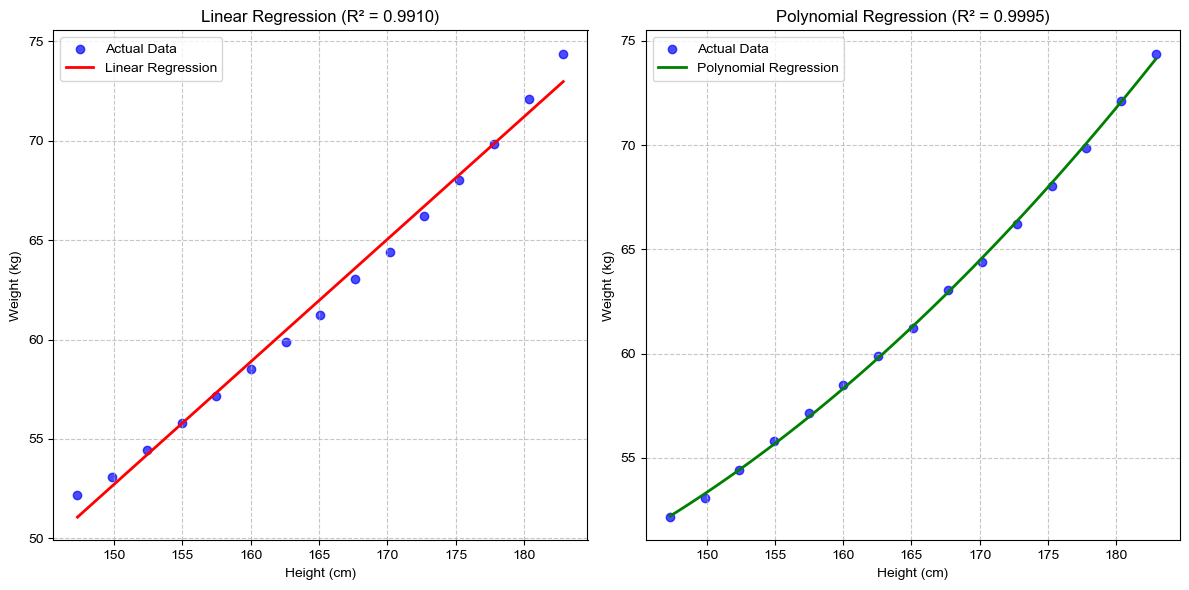

In [8]:
'''
## 6. 可视化回归结果
'''

# 创建用于绘图的连续值
X_continuous = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_linear_continuous = linear_model.predict(X_continuous)
y_poly_continuous = poly_model.predict(X_continuous)

# 绘制回归结果
plt.figure(figsize=(12, 6))

# 线性回归结果
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data' if use_english_labels else '实际数据')
plt.plot(X_continuous, y_linear_continuous, color='red', linewidth=2, label='Linear Regression' if use_english_labels else '线性回归')
plt.title(f'Linear Regression (R² = {r2_linear:.4f})' if use_english_labels else f'线性回归 (R² = {r2_linear:.4f})')
plt.xlabel('Height (cm)' if use_english_labels else '身高 (厘米)')
plt.ylabel('Weight (kg)' if use_english_labels else '体重 (千克)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 非线性回归结果
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data' if use_english_labels else '实际数据')
plt.plot(X_continuous, y_poly_continuous, color='green', linewidth=2, label='Polynomial Regression' if use_english_labels else '二次多项式回归')
plt.title(f'Polynomial Regression (R² = {r2_poly:.4f})' if use_english_labels else f'二次多项式回归 (R² = {r2_poly:.4f})')
plt.xlabel('Height (cm)' if use_english_labels else '身高 (厘米)')
plt.ylabel('Weight (kg)' if use_english_labels else '体重 (千克)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig('regression_results.png')  # 保存图片
plt.show()

In [9]:
'''
## 7. 比较线性回归和非线性回归
'''

# 比较两种模型
model_comparison = pd.DataFrame({
    'Model' if use_english_labels else '模型': ['Linear Regression' if use_english_labels else '线性回归', 
                                              'Polynomial Regression' if use_english_labels else '二次多项式回归'],
    'R²': [r2_linear, r2_poly],
    'MSE': [mse_linear, mse_poly]
})

print("Model Comparison:" if use_english_labels else "模型比较：")
print(model_comparison)

# 判断哪个模型更好
better_model = 'Linear Regression' if r2_linear >= r2_poly else 'Polynomial Regression' if use_english_labels else '线性回归' if r2_linear >= r2_poly else '二次多项式回归'
print(f"\nBased on R² value, {better_model} model performs better." if use_english_labels else f"\n根据R²值，{better_model}模型表现更好。")

Model Comparison:
                   Model        R²       MSE
0      Linear Regression  0.991010  0.414693
1  Polynomial Regression  0.999474  0.024279

Based on R² value, Polynomial Regression model performs better.


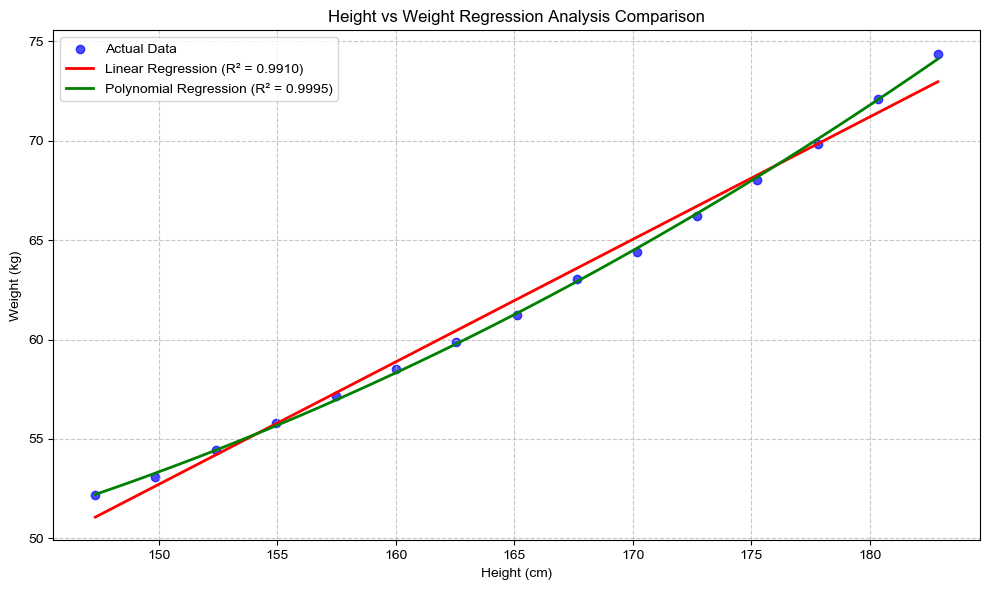

In [10]:
'''
## 8. 在同一图表上比较两种模型
'''

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data' if use_english_labels else '实际数据')
plt.plot(X_continuous, y_linear_continuous, color='red', linewidth=2, 
         label=f'Linear Regression (R² = {r2_linear:.4f})' if use_english_labels else f'线性回归 (R² = {r2_linear:.4f})')
plt.plot(X_continuous, y_poly_continuous, color='green', linewidth=2, 
         label=f'Polynomial Regression (R² = {r2_poly:.4f})' if use_english_labels else f'二次多项式回归 (R² = {r2_poly:.4f})')
plt.title('Height vs Weight Regression Analysis Comparison' if use_english_labels else '女性身高与体重回归分析比较')
plt.xlabel('Height (cm)' if use_english_labels else '身高 (厘米)')
plt.ylabel('Weight (kg)' if use_english_labels else '体重 (千克)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('comprehensive_comparison.png')  # 保存图片
plt.show()
